# 05. Black-Litterman 융합 + MVO 최적화

**목표**: RL 배분 + 인간 배분 → 역최적화 → BL 융합 → MVO → 최종 ETF 비중 `w*`

| 단계 | 내용 |
|------|------|
| 1 | Prior 로드 (Σ, Π, δ) |
| 2 | `w_RL` 로드 + 인간 배분 `w_Human` 입력 |
| 3 | 역최적화: `Q_RL = δΣw_RL`, `Q_Human = δΣw_Human` |
| 4 | BL 융합: P, Q, Ω 조합 → 사후 수익률 `E[R]` |
| 5 | MVO (scipy, 하드 제약) → `w*` |
| 6 | 월별 롤링 백테스트 + 성과 분석 |

**입력**: `03_black_litterman_prior.ipynb` + `04_rl_portfolio_agent.ipynb` 산출물  
**출력**: 최종 ETF 비중 `w*`, 백테스트 성과 보고서

In [ ]:
import sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    !pip install -q scipy scikit-learn
    !apt-get install -y fonts-nanum -qq
    import matplotlib.font_manager as fm
    fm._load_fontmanager(try_read_cache=False)


In [2]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import warnings
from scipy.optimize import minimize
warnings.filterwarnings('ignore')

matplotlib.rcParams['font.family'] = 'NanumGothic' if IN_COLAB else 'AppleGothic'
matplotlib.rcParams['axes.unicode_minus'] = False

if IN_COLAB:
    DRIVE_ROOT = '/content/drive/MyDrive/졸업프로젝트/GAPS_대회'
else:
    DRIVE_ROOT = os.path.expanduser('~/school/4-1/졸업프로젝트/GAPS_대회')

DATA_DIR = os.path.join(DRIVE_ROOT, 'data')
print('DATA_DIR:', DATA_DIR)

DATA_DIR: /content/drive/MyDrive/졸업프로젝트/GAPS_대회/data


## Step 1 — Prior 로드 (03 노트북 산출물)

In [ ]:
# ── 카테고리 정의 (04 노트북과 동일) ─────────────────────────────────────────
CATEGORIES = [
    'fx_commodity', 'overseas_index', 'overseas_sector',
    'domestic_index', 'domestic_sector',
    'mmf_ultrashort', 'overseas_bond_corp', 'overseas_bond',
    'domestic_bond_corp', 'domestic_bond',
]
CAT_LABELS_KR = [
    'FX/원자재', '해외주식_지수', '해외주식_섹터',
    '국내주식_지수', '국내주식_섹터',
    '초단기채권', '해외채권_회사채', '해외채권_종합',
    '국내채권_회사채', '국내채권_종합',
]
RISK_IDX = [0, 1, 2, 3, 4]
SAFE_IDX = [5, 6, 7, 8, 9]
N_CATS = len(CATEGORIES)

# ── 대회 규정: 증거금 내 세부자산별 상한 ─────────────────────────────────────
CAT_UPPER_BOUNDS = np.array([
    0.20,  # fx_commodity       — FX 및 원자재 ≤ 20%
    0.30,  # overseas_index     — 해외주식_지수 ≤ 30%
    0.10,  # overseas_sector    — 해외주식_섹터 ≤ 10%
    0.30,  # domestic_index     — 국내주식_지수 ≤ 30%
    0.15,  # domestic_sector    — 국내주식_섹터 ≤ 15%
    0.50,  # mmf_ultrashort     — 금리연계형/초단기채권 ≤ 50%
    0.30,  # overseas_bond_corp — 해외채권_회사채 ≤ 30%
    0.50,  # overseas_bond      — 해외채권_종합 ≤ 50%
    0.30,  # domestic_bond_corp — 국내채권_회사채 ≤ 30%
    0.50,  # domestic_bond      — 국내채권_종합 ≤ 50%
])

# ── 메타 정보 로드 ────────────────────────────────────────────────────────────
with open(os.path.join(DATA_DIR, 'bl_meta.json'), encoding='utf-8') as f:
    bl_meta = json.load(f)

delta      = bl_meta['delta']
r_f_annual = bl_meta['r_f']
r_f_monthly = r_f_annual / 12
tickers_final = bl_meta['tickers']
N = len(tickers_final)

# ── 카테고리 레벨 Prior 로드 (04 노트북 산출물) ───────────────────────────────
Sigma_cat  = np.load(os.path.join(DATA_DIR, 'bl_sigma_cat.npy'))    # (10, 10)
Pi_cat     = np.load(os.path.join(DATA_DIR, 'bl_pi_cat.npy'))        # (10,)
w_mkt_cat  = np.load(os.path.join(DATA_DIR, 'bl_w_mkt_cat.npy'))    # (10,)

print(f'δ = {delta:.4f},  r_f = {r_f_annual:.2%}')
print(f'Σ_cat shape: {Sigma_cat.shape}')
print('세부자산별 상한:')
for c, ub in zip(CAT_LABELS_KR, CAT_UPPER_BOUNDS):
    print(f'  {c:<16s}: ≤ {ub:.0%}')
print(f'Π_cat (연율화 균형수익률):')
for c, p in zip(CAT_LABELS_KR, Pi_cat):
    print(f'  {c:<16s}: {p:.4%}')

In [4]:
# ── ETF 레벨 Prior 로드 (03 노트북 산출물, MVO에서 사용) ──────────────────────
Sigma_etf = pd.read_parquet(os.path.join(DATA_DIR, 'bl_sigma.parquet'))
Pi_etf    = pd.read_csv(os.path.join(DATA_DIR, 'bl_pi.csv'), index_col=0).squeeze()
w_mkt_etf = pd.read_csv(os.path.join(DATA_DIR, 'bl_w_mkt.csv'), index_col=0).squeeze()

# 순서 정렬
Sigma_etf = Sigma_etf.loc[tickers_final, tickers_final]
Pi_etf    = Pi_etf.reindex(tickers_final).fillna(0.0)
w_mkt_etf = w_mkt_etf.reindex(tickers_final).fillna(0.0)
w_mkt_etf = w_mkt_etf / w_mkt_etf.sum()

print(f'ETF 레벨 Σ shape: {Sigma_etf.shape}')
print(f'ETF 수: {N}')

ETF 레벨 Σ shape: (131, 131)
ETF 수: 131


In [ ]:
# ── 카테고리 → ETF 매핑 (AUM 비례 배분) ────────────────────────────────────────
import sys
sys.path.insert(0, os.path.join(DRIVE_ROOT, 'src'))
from etf_universe import ETF_LIST

etf_df = pd.DataFrame(ETF_LIST)
etf_df = etf_df[~etf_df['special_ticker'].fillna(False).astype(bool)]
ticker_to_cat = etf_df.set_index('ticker')['category'].to_dict()
ticker_to_aum = etf_df.set_index('ticker')['aum'].to_dict()
ticker_to_risk = etf_df.set_index('ticker')['is_risk'].to_dict()

risk_mask = np.array([ticker_to_risk.get(t, False) for t in tickers_final])
print(f'위험자산 ETF 수: {risk_mask.sum()}')

# ── 거래량 필터 설정 (아래 셀에서 LIQUID_TICKERS 채움) ────────────────────────
LIQUID_TICKERS = None        # None이면 전체 허용, set이면 해당 티커만 허용
MIN_DAILY_VALUE = 1_000_000_000  # 일평균 거래대금 기준: 10억원/일


def cat_weights_to_etf(w_cat: np.ndarray) -> np.ndarray:
    """카테고리 비중 (10,) → ETF 비중 (N,), AUM 비례 배분
    LIQUID_TICKERS가 설정된 경우 유동성 낮은 종목은 제외 후 AUM 재정규화
    """
    w_etf = np.zeros(N)
    for cat_idx, cat_name in enumerate(CATEGORIES):
        cat_tickers = [t for t in tickers_final if ticker_to_cat.get(t) == cat_name]
        if LIQUID_TICKERS is not None:
            cat_tickers = [t for t in cat_tickers if t in LIQUID_TICKERS]
        if not cat_tickers:
            continue
        aum_vals = np.array([ticker_to_aum.get(t, 1.0) for t in cat_tickers])
        aum_w = aum_vals / aum_vals.sum()
        for j, t in enumerate(cat_tickers):
            etf_idx = tickers_final.index(t)
            w_etf[etf_idx] = w_cat[cat_idx] * aum_w[j]
    total = w_etf.sum()
    return w_etf / total if total > 1e-8 else w_etf


# 검증: 균등 카테고리 배분이 올바르게 매핑되는지
w_equal_cat = np.ones(N_CATS) / N_CATS
w_equal_etf = cat_weights_to_etf(w_equal_cat)
print(f'매핑 검증 — ETF 비중 합계: {w_equal_etf.sum():.6f}')
print(f'위험자산 비중 (균등 배분): {w_equal_etf[risk_mask].sum():.4%}')

## Step 2 — `w_RL` 로드 + `w_Human` 입력

In [ ]:
# ── AI 예측 기반 w_RL 로드 (ai_pred_weekly → 월별 카테고리 비중 변환) ──────────
from scipy.special import softmax

ai_pred_df = pd.read_parquet(os.path.join(DATA_DIR, 'ai_pred_weekly.parquet'))
ai_pred_df.index = pd.to_datetime(ai_pred_df.index)

# 주별 → 월말 평균
ai_pred_monthly = ai_pred_df.resample('ME').mean()

# 예측 수익률 → 포트폴리오 비중 (softmax, temperature=20)
TEMP = 20.0
w_RL_df = pd.DataFrame(
    [softmax(row * TEMP) for row in ai_pred_monthly.values],
    index=ai_pred_monthly.index,
    columns=CATEGORIES,
)
print(f'AI 예측 기반 w_RL 로드 완료: {w_RL_df.shape}')
print(f'기간: {w_RL_df.index[0].date()} ~ {w_RL_df.index[-1].date()}')
w_RL_df.tail(3)

In [ ]:
# ── 인간 운용역 정성 분석 결과 입력 ──────────────────────────────────────────
# ※ 이 값은 팀 회의에서 결정된 카테고리 목표 비중
# ※ 매월 업데이트 가능.
#
# 인간 운용역 배분 (2026-07-05 갱신):
#   위험: 코스피 10%, S&P500 15%, 나스닥 15%, 금 10%
#   안전: 한국초단기 20%, 미국중기 30%
#   → 위험자산 50% (domestic_index 10%, overseas_index 30%, fx_commodity 10%)

w_Human_cat = np.array([
    0.10,   # fx_commodity     (금)
    0.30,   # overseas_index   (S&P500 15% + 나스닥 15%)
    0.00,   # overseas_sector
    0.10,   # domestic_index   (코스피)
    0.00,   # domestic_sector
    0.20,   # mmf_ultrashort   (한국초단기)
    0.00,   # overseas_bond_corp
    0.30,   # overseas_bond    (미국중기)
    0.00,   # domestic_bond_corp
    0.00,   # domestic_bond
])

assert abs(w_Human_cat.sum() - 1.0) < 1e-5, f'합계 ≠ 1: {w_Human_cat.sum():.6f}'
risk_human = w_Human_cat[RISK_IDX].sum()
assert risk_human <= 0.701, f'위험자산 제약 위반: {risk_human:.4%}'

print('w_Human 입력 완료:')
for i, (c, w) in enumerate(zip(CAT_LABELS_KR, w_Human_cat)):
    risk_str = '(위험)' if i in RISK_IDX else '(안전)'
    print(f'  {c:<16s}: {w:.2%}  {risk_str}')
print(f'위험자산 합계: {risk_human:.2%}  ({"≤70% ✓" if risk_human <= 0.70 else ">70% ✗"})')

## Step 3 — 역최적화: `Q = δΣw`

In [8]:
def reverse_optimize(w_cat: np.ndarray, delta: float, Sigma_cat: np.ndarray) -> np.ndarray:
    """
    역최적화 (Reverse Optimization)
    w_cat: 카테고리 배분 비중 (10,)
    반환: 해당 배분을 CAPM 균형으로 정당화하는 암묵적 기대수익률 (10,)

    공식: Q = δ · Σ_cat · w
    """
    return delta * Sigma_cat @ w_cat


# 인간 뷰 (고정, 매월 동일)
Q_Human = reverse_optimize(w_Human_cat, delta, Sigma_cat)

print('Q_Human (인간 운용역 암묵적 기대수익률, 연율화):')
for c, q in zip(CAT_LABELS_KR, Q_Human):
    print(f'  {c:<16s}: {q:.4%}')

print(f'\n균형 수익률 Π_cat 대비 인간 뷰 편차:')
diff = Q_Human - Pi_cat
for c, d in zip(CAT_LABELS_KR, diff):
    sign = '+' if d >= 0 else ''
    print(f'  {c:<16s}: {sign}{d:.4%}')

Q_Human (인간 운용역 암묵적 기대수익률, 연율화):
  FX/원자재          : 3.3678%
  해외주식_지수         : 7.1868%
  해외주식_섹터         : 6.7188%
  국내주식_지수         : 12.8824%
  국내주식_섹터         : 13.7649%
  초단기채권           : 0.4130%
  해외채권_회사채        : 1.2627%
  해외채권_종합         : 0.0750%
  국내채권_회사채        : 0.4637%
  국내채권_종합         : 0.5593%

균형 수익률 Π_cat 대비 인간 뷰 편차:
  FX/원자재          : -1.1621%
  해외주식_지수         : -4.7002%
  해외주식_섹터         : -4.6689%
  국내주식_지수         : -17.3070%
  국내주식_섹터         : -18.9366%
  초단기채권           : +0.3234%
  해외채권_회사채        : +0.0186%
  해외채권_종합         : +2.1778%
  국내채권_회사채        : -0.6609%
  국내채권_종합         : -0.3650%


## Step 4 — Black-Litterman 융합

In [9]:
def black_litterman_two_views(
    Pi: np.ndarray,
    Sigma: np.ndarray,
    Q_RL: np.ndarray,
    Q_Human: np.ndarray,
    Omega_RL: float,
    Omega_Human: float,
    tau: float = 0.05,
):
    """
    두 독립 뷰(RL + 인간)를 BL로 융합.

    P = [I_10 ; I_10]  (두 뷰 모두 전체 카테고리에 대한 절대 뷰)
    Q = [Q_RL ; Q_Human]
    Ω = diag(Omega_RL·I_10, Omega_Human·I_10)

    P = [I; I]이므로:
      P^T Ω^-1 P = Ω_RL^-1·I + Ω_Human^-1·I
      P^T Ω^-1 Q = Ω_RL^-1·Q_RL + Ω_Human^-1·Q_Human

    반환: E_R (사후 기대수익률, 10,), Sigma_post (10, 10)
    """
    N = len(Pi)
    tau_Sigma_inv = np.linalg.inv(tau * Sigma)
    omega_RL_inv  = (1.0 / Omega_RL)  * np.eye(N)
    omega_Hu_inv  = (1.0 / Omega_Human) * np.eye(N)

    # 사후 정밀도 행렬
    M_inv = tau_Sigma_inv + omega_RL_inv + omega_Hu_inv
    M = np.linalg.inv(M_inv)  # 사후 공분산 (불확실성)

    # 사후 기대수익률
    E_R = M @ (
        tau_Sigma_inv @ Pi
        + omega_RL_inv @ Q_RL
        + omega_Hu_inv @ Q_Human
    )

    # 사후 공분산 (BL 표준: 모수 불확실성 포함)
    Sigma_post = Sigma + M

    return E_R, Sigma_post


# ── Ω 설정 전략 ────────────────────────────────────────────────────────────
# Ω가 작을수록 해당 뷰를 강하게 신뢰
# 기본값: RL과 인간을 동등하게 신뢰
# 국면 감지를 통해 동적으로 조절 가능 (아래 Step 5에서 구현)

OMEGA_RL_DEFAULT    = 0.02   # RL 뷰 기본 불확실성
OMEGA_HUMAN_DEFAULT = 0.02   # 인간 뷰 기본 불확실성
TAU = 0.05

# 예시: 최신 w_RL로 BL 계산
w_RL_latest = w_RL_df.iloc[-1].values
Q_RL_latest = reverse_optimize(w_RL_latest, delta, Sigma_cat)

E_R_test, Sigma_post_test = black_litterman_two_views(
    Pi_cat, Sigma_cat, Q_RL_latest, Q_Human,
    OMEGA_RL_DEFAULT, OMEGA_HUMAN_DEFAULT, TAU
)

print('BL 사후 기대수익률 예시 (최신 w_RL 기준):')
print(f'{'카테고리':<16s}  {'Prior Π':<10s}  {'Q_RL':<10s}  {'Q_Human':<10s}  {'E[R] 사후':<10s}')
print('-' * 70)
for i, c in enumerate(CAT_LABELS_KR):
    print(f'{c:<16s}  {Pi_cat[i]:>8.4%}  {Q_RL_latest[i]:>8.4%}  {Q_Human[i]:>8.4%}  {E_R_test[i]:>8.4%}')

BL 사후 기대수익률 예시 (최신 w_RL 기준):
카테고리              Prior Π     Q_RL        Q_Human     E[R] 사후   
----------------------------------------------------------------------
FX/원자재             4.5299%   4.0399%   3.3678%   3.5105%
해외주식_지수           11.8870%   5.8332%   7.1868%   9.3336%
해외주식_섹터           11.3877%   6.2670%   6.7188%   8.8639%
국내주식_지수           30.1894%  14.0516%  12.8824%  22.0432%
국내주식_섹터           32.7015%  15.4474%  13.7649%  23.6916%
초단기채권              0.0895%   0.2265%   0.4130%   0.0898%
해외채권_회사채           1.2442%   1.3196%   1.2627%   1.1137%
해외채권_종합           -2.1028%  -0.2388%   0.0750%  -1.3227%
국내채권_회사채           1.1246%   0.7605%   0.4637%   0.8662%
국내채권_종합            0.9242%   0.6677%   0.5593%   0.6939%


## Step 5 — MVO 최적화 (하드 제약)

In [ ]:
def mvo_optimize(
    E_R_cat: np.ndarray,
    Sigma_cat: np.ndarray,
    w_prev_cat: np.ndarray,
    lambda_risk: float = 1.5,
    max_risk: float = 0.70,
    min_turnover: float = 0.10,
) -> np.ndarray:
    """
    MVO (평균-분산 최적화) — 카테고리 레벨

    목적함수: E[R]^T w - (λ/2) w^T Σ w  (최대화)

    하드 제약:
      ① 위험자산(카테고리 0~4) 합계 ≤ 70%
      ② 세부자산별 상한 (CAT_UPPER_BOUNDS): 대회 규정
      ③ 모든 w_i ≥ 0
      ④ Σw_i = 1.0
      ⑤ L1 회전율 = |w - w_prev|₁ ≥ 10%

    반환: 최적 카테고리 비중 (10,)
    """
    N = len(E_R_cat)

    def neg_utility(w):
        return -(E_R_cat @ w - (lambda_risk / 2) * w @ Sigma_cat @ w)

    def neg_utility_grad(w):
        return -(E_R_cat - lambda_risk * Sigma_cat @ w)

    constraints = [
        # 완전 투자
        {'type': 'eq', 'fun': lambda w: w.sum() - 1.0,
         'jac': lambda w: np.ones(N)},
        # 위험자산 합계 ≤ 70%
        {'type': 'ineq',
         'fun': lambda w: max_risk - w[RISK_IDX].sum(),
         'jac': lambda w: -np.array([1.0 if i in RISK_IDX else 0.0 for i in range(N)])},
        # 회전율 ≥ 10%
        {'type': 'ineq',
         'fun': lambda w: np.abs(w - w_prev_cat).sum() - min_turnover},
    ]
    # 세부자산별 상한 적용 (대회 규정)
    bounds = [(0.0, float(CAT_UPPER_BOUNDS[i])) for i in range(N)]

    # 초기값: 이전 비중 클리핑 후 정규화
    w0 = np.clip(w_prev_cat.copy(), 0, CAT_UPPER_BOUNDS)
    w0 += np.random.uniform(-0.02, 0.02, N)
    w0 = np.clip(w0, 0, CAT_UPPER_BOUNDS)
    w0 /= w0.sum()

    result = minimize(
        neg_utility, w0,
        jac=neg_utility_grad,
        method='SLSQP',
        bounds=bounds,
        constraints=constraints,
        options={'maxiter': 2000, 'ftol': 1e-10, 'disp': False},
    )

    if result.success:
        w_opt = np.clip(result.x, 0, CAT_UPPER_BOUNDS)
        w_opt /= w_opt.sum()
        return w_opt
    else:
        print(f'  MVO 실패: {result.message} → fallback')
        return np.clip(w_prev_cat, 0, CAT_UPPER_BOUNDS) / np.clip(w_prev_cat, 0, CAT_UPPER_BOUNDS).sum()


# ── 제약 검증 출력 ────────────────────────────────────────────────────────────
print('세부자산별 bounds (대회 규정 적용):')
for c, ub in zip(CAT_LABELS_KR, CAT_UPPER_BOUNDS):
    group = '(위험)' if c in ['FX/원자재','해외주식_지수','해외주식_섹터','국내주식_지수','국내주식_섹터'] else '(안전)'
    print(f'  {c:<16s}: 0% ~ {ub:.0%}  {group}')


# ── 국면 감지 기반 Ω 동적 조절 ──────────────────────────────────────────────
def compute_omega(cat_ret_window: np.ndarray,
                  base_omega_rl: float = 0.02,
                  base_omega_human: float = 0.02,
                  vol_threshold: float = 0.05) -> tuple:
    """
    최근 3개월 카테고리 변동성으로 국면 감지
    → 위기 국면이면 인간 뷰 신뢰도 높임 (Ω_Human 낮춤)
    → 평온 국면이면 RL 뷰 신뢰도 높임 (Ω_RL 낮춤)
    """
    if len(cat_ret_window) < 3:
        return base_omega_rl, base_omega_human

    recent_vol = cat_ret_window[-3:].std(axis=0).mean()

    if recent_vol > vol_threshold:
        omega_rl    = base_omega_rl * 3.0
        omega_human = base_omega_human * 0.5
    else:
        omega_rl    = base_omega_rl * 0.5
        omega_human = base_omega_human * 2.0

    return omega_rl, omega_human

## Step 6 — 월별 롤링 백테스트

In [11]:
# ── 카테고리 수익률 로드 ──────────────────────────────────────────────────────
# (04 노트북에서 계산한 것과 동일한 방법으로 재계산 또는 저장된 파일 로드)
# 여기서는 ETF 가격에서 직접 계산

price_df = pd.read_parquet(os.path.join(DATA_DIR, 'etf_close_wide.parquet'))
price_df.index = pd.to_datetime(price_df.index)
price_df = price_df.sort_index()

CRIT_DATE = '2021-01-01'
price_sub = price_df.loc[CRIT_DATE:, [t for t in tickers_final if t in price_df.columns]].ffill()
monthly_price = price_sub.resample('ME').last()
monthly_ret_etf = monthly_price.pct_change().dropna(how='all')

# 카테고리별 AUM 가중 수익률
cat_ret_dict = {}
for cat in CATEGORIES:
    cat_tickers = [t for t in tickers_final if ticker_to_cat.get(t) == cat and t in monthly_ret_etf.columns]
    if not cat_tickers:
        cat_ret_dict[cat] = pd.Series(0.0, index=monthly_ret_etf.index)
        continue
    aum_w = pd.Series({t: ticker_to_aum.get(t, 1.0) for t in cat_tickers})
    aum_w /= aum_w.sum()
    cat_ret_dict[cat] = (monthly_ret_etf[cat_tickers] * aum_w).sum(axis=1)

cat_ret = pd.DataFrame(cat_ret_dict, columns=CATEGORIES).dropna()
print(f'카테고리 수익률: {cat_ret.shape}')

카테고리 수익률: (65, 10)


In [ ]:
# ── 백테스트 메인 루프 ────────────────────────────────────────────────────────
np.random.seed(42)

WARMUP = 12

TEST_START = pd.Timestamp('2025-01-01')

results = []

train_dates_rl = w_RL_df.index[w_RL_df.index < TEST_START]
if len(train_dates_rl) > 0:
    w_cat_prev = w_RL_df.loc[train_dates_rl[-1]].values.copy()
    w_cat_prev = np.clip(w_cat_prev, 0, CAT_UPPER_BOUNDS)
    w_cat_prev /= w_cat_prev.sum()
    print(f'초기 비중: RL 훈련 마지막 달 ({train_dates_rl[-1].date()}) 배분 사용')
else:
    w_cat_prev = w_mkt_cat.copy()
    print('초기 비중: 시장 균형 비중 사용')

all_valid_dates = w_RL_df.index.intersection(cat_ret.index[WARMUP:])
in_sample_dates = all_valid_dates[all_valid_dates < TEST_START]
common_dates    = all_valid_dates[all_valid_dates >= TEST_START]

print(f'\n[제외] In-Sample 구간: 2022-02 ~ 2024-12 ({len(in_sample_dates)}개월) — RL 학습 데이터이므로 사용 불가')
print(f'[사용] OOS 백테스트 구간: {common_dates[0].date()} ~ {common_dates[-1].date()} ({len(common_dates)}개월)')

for date in common_dates:
    hist_ret = cat_ret.loc[:date].iloc[:-1]

    from sklearn.covariance import LedoitWolf
    window_ret = hist_ret.tail(36).values
    if len(window_ret) >= 12:
        lw = LedoitWolf()
        lw.fit(window_ret)
        Sigma_t = lw.covariance_ * 12
    else:
        Sigma_t = Sigma_cat

    w_RL_t = w_RL_df.loc[date].values
    Q_RL_t = reverse_optimize(w_RL_t, delta, Sigma_t)
    Q_Human_t = reverse_optimize(w_Human_cat, delta, Sigma_t)

    omega_rl, omega_human = compute_omega(hist_ret.tail(6).values)

    Pi_t = delta * Sigma_t @ w_mkt_cat
    E_R_cat, Sigma_post = black_litterman_two_views(
        Pi_t, Sigma_t, Q_RL_t, Q_Human_t, omega_rl, omega_human, TAU
    )

    w_cat_opt = mvo_optimize(E_R_cat, Sigma_t, w_cat_prev)

    cat_ret_t = cat_ret.loc[date].values
    port_ret = (w_cat_opt * cat_ret_t).sum()

    turnover = np.abs(w_cat_opt - w_cat_prev).sum()
    tc = 0.001 * turnover
    net_ret = port_ret - tc

    results.append({
        'date': date,
        'port_ret': port_ret,
        'net_ret': net_ret,
        'turnover': turnover,
        'risk_weight': w_cat_opt[RISK_IDX].sum(),
        'omega_rl': omega_rl,
        'omega_human': omega_human,
        **{f'w_{cat}': w_cat_opt[i] for i, cat in enumerate(CATEGORIES)}
    })

    w_cat_prev = w_cat_opt.copy()

results_df = pd.DataFrame(results).set_index('date')

# ── 제약 위반 검증 ────────────────────────────────────────────────────────────
print(f'\n백테스트 완료: {len(results_df)}개월 (순수 OOS)')
print(f'위험자산 합계 제약 위반 (>70%): {(results_df["risk_weight"] > 0.701).sum()}회')
print(f'회전율 부족 (<10%): {(results_df["turnover"] < 0.09).sum()}회')
print('\n세부자산별 상한 위반 검증:')
any_viol = False
for i, (cat, ub) in enumerate(zip(CATEGORIES, CAT_UPPER_BOUNDS)):
    col = f'w_{cat}'
    viol = (results_df[col] > ub + 0.001).sum()
    if viol > 0:
        print(f'  ✗ {CAT_LABELS_KR[i]:<16s}: {viol}회 위반 (상한 {ub:.0%})')
        any_viol = True
if not any_viol:
    print('  ✓ 모든 세부자산 제약 준수')

In [13]:
# ── 성과 분석 (OOS 기간만) ────────────────────────────────────────────────────

def performance_summary(returns: pd.Series, label: str, r_f: float = 0.035/12):
    n = len(returns)
    cagr = (1 + returns).prod() ** (12 / n) - 1
    excess = returns - r_f
    sharpe = excess.mean() / excess.std() * np.sqrt(12) if excess.std() > 0 else 0
    cumret = (1 + returns).cumprod()
    mdd = ((cumret - cumret.cummax()) / cumret.cummax()).min()
    vol = returns.std() * np.sqrt(12)
    return {'전략': label, 'CAGR': cagr, 'Sharpe': sharpe, 'MDD': mdd, '연변동성': vol}


# BL 전략 (거래비용 후, OOS만)
bl_ret = results_df['net_ret']
oos_start = bl_ret.index[0]
oos_end   = bl_ret.index[-1]

# 벤치마크도 동일한 OOS 기간으로 맞춤
bm_ret = cat_ret.loc[bl_ret.index].mean(axis=1)

# RL only — OOS 구간만 자름
rl_ret_csv = os.path.join(DATA_DIR, 'rl_portfolio_returns.csv')
if os.path.exists(rl_ret_csv):
    rl_ret = pd.read_csv(rl_ret_csv, index_col=0, parse_dates=True).squeeze()
    rl_ret = rl_ret.reindex(bl_ret.index).fillna(0)
else:
    rl_ret = None

metrics = [
    performance_summary(bl_ret, 'BL (RL+Human, 제안 전략)'),
    performance_summary(bm_ret, '균등 카테고리 배분 (BM)'),
]
if rl_ret is not None:
    metrics.append(performance_summary(rl_ret, 'RL only'))

perf_df = pd.DataFrame(metrics).set_index('전략')

print('=' * 70)
print(f'OOS 백테스트 성과 요약 ({oos_start.date()} ~ {oos_end.date()})')
print('※ RL·AI 모델 훈련 구간(~2024-12) 완전 제외 — 진정한 Out-of-Sample')
print('=' * 70)
print(perf_df.applymap(lambda x: f'{x:.4%}' if isinstance(x, float) else x).to_string())

OOS 백테스트 성과 요약 (2025-01-31 ~ 2026-06-30)
※ RL·AI 모델 훈련 구간(~2024-12) 완전 제외 — 진정한 Out-of-Sample
                          CAGR     Sharpe        MDD      연변동성
전략                                                            
BL (RL+Human, 제안 전략)  99.0837%  220.2060%  -11.5398%  32.7358%
균등 카테고리 배분 (BM)       35.5402%  235.4519%   -4.0549%  11.8687%
RL only               37.2697%  235.2773%   -4.3119%  12.4586%


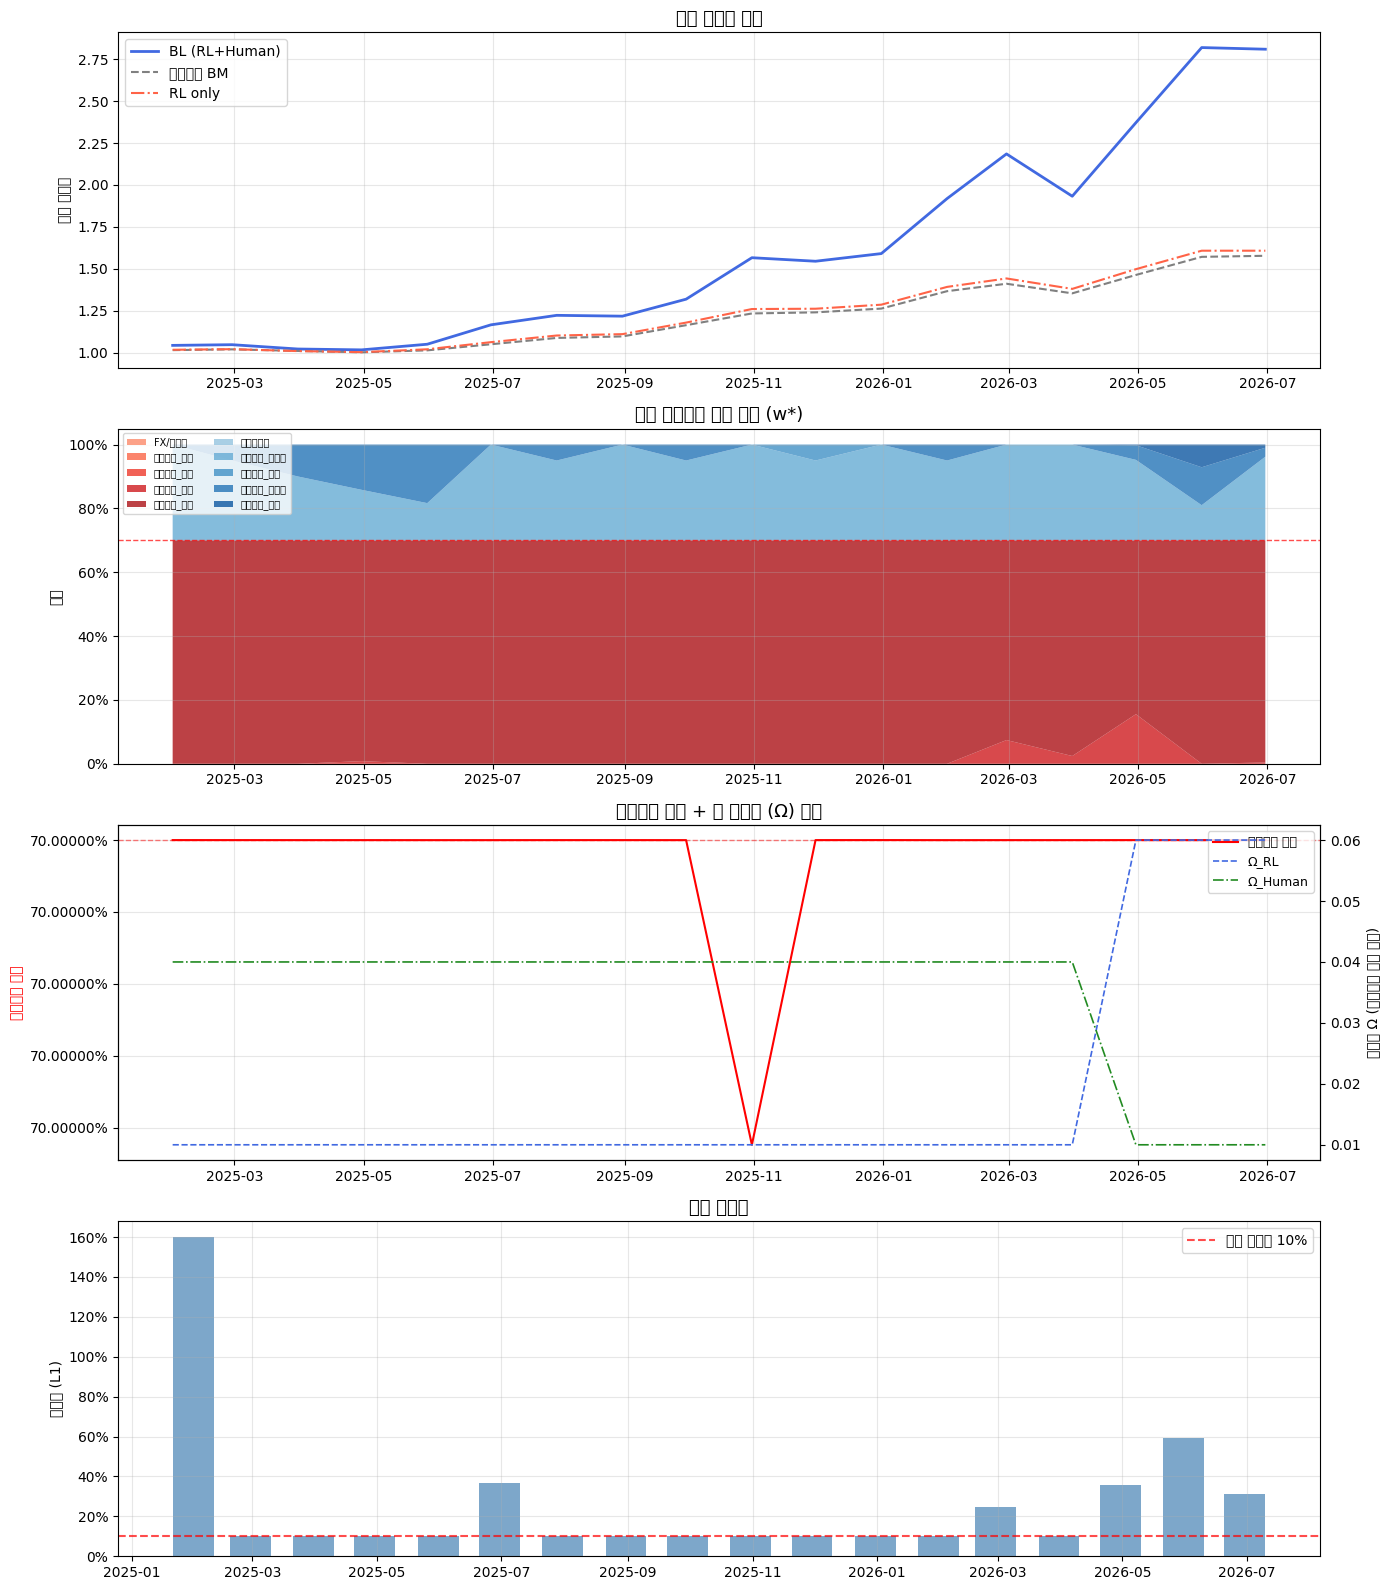

In [14]:
# ── 시각화 ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(14, 16))

# 1. 누적 수익률 비교
cumret_bl = (1 + bl_ret).cumprod()
cumret_bm = (1 + bm_ret).cumprod()
axes[0].plot(cumret_bl.index, cumret_bl.values, label='BL (RL+Human)', linewidth=2, color='royalblue')
axes[0].plot(cumret_bm.index, cumret_bm.values, label='균등분산 BM', linewidth=1.5,
              color='gray', linestyle='--')
if rl_ret is not None:
    cumret_rl = (1 + rl_ret).cumprod()
    axes[0].plot(cumret_rl.index, cumret_rl.values, label='RL only',
                  linewidth=1.5, color='tomato', linestyle='-.')
axes[0].set_title('누적 수익률 비교', fontsize=13)
axes[0].set_ylabel('누적 수익률')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. 카테고리 배분 (스택)
w_cols = [f'w_{c}' for c in CATEGORIES]
w_hist = results_df[w_cols]
colors_risk = list(plt.cm.Reds(np.linspace(0.4, 0.85, 5)))
colors_safe = list(plt.cm.Blues(np.linspace(0.4, 0.85, 5)))
axes[1].stackplot(w_hist.index, w_hist.values.T,
                   labels=CAT_LABELS_KR,
                   colors=colors_risk + colors_safe, alpha=0.8)
axes[1].axhline(0.70, color='red', linestyle='--', alpha=0.7, linewidth=1)
axes[1].set_title('최종 카테고리 배분 비중 (w*)', fontsize=13)
axes[1].set_ylabel('비중')
axes[1].yaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(xmax=1))
axes[1].legend(loc='upper left', fontsize=7, ncol=2)
axes[1].grid(True, alpha=0.3)

# 3. 위험자산 비중 + Ω 신뢰도
ax3 = axes[2]
ax3_twin = ax3.twinx()
ax3.plot(results_df.index, results_df['risk_weight'], color='red', linewidth=1.5, label='위험자산 비중')
ax3.axhline(0.70, color='red', linestyle='--', alpha=0.5, linewidth=1)
ax3.set_ylabel('위험자산 비중', color='red')
ax3.yaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(xmax=1))
ax3_twin.plot(results_df.index, results_df['omega_rl'], color='royalblue',
               linewidth=1.2, linestyle='--', label='Ω_RL')
ax3_twin.plot(results_df.index, results_df['omega_human'], color='forestgreen',
               linewidth=1.2, linestyle='-.', label='Ω_Human')
ax3_twin.set_ylabel('신뢰도 Ω (작을수록 강한 신뢰)')
ax3.set_title('위험자산 비중 + 뷰 신뢰도 (Ω) 추이', fontsize=13)
lines1, labels1 = ax3.get_legend_handles_labels()
lines2, labels2 = ax3_twin.get_legend_handles_labels()
ax3.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=9)
ax3.grid(True, alpha=0.3)

# 4. 월별 회전율
axes[3].bar(results_df.index, results_df['turnover'], width=20, alpha=0.7, color='steelblue')
axes[3].axhline(0.10, color='red', linestyle='--', alpha=0.7, label='최소 회전율 10%')
axes[3].set_title('월별 회전율', fontsize=13)
axes[3].set_ylabel('회전율 (L1)')
axes[3].yaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(xmax=1))
axes[3].legend()
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'bl_backtest_result.png'), dpi=150)
plt.show()

In [15]:
# ── 결과 저장 ─────────────────────────────────────────────────────────────────
results_df.to_parquet(os.path.join(DATA_DIR, 'bl_backtest_results.parquet'))
perf_df.to_csv(os.path.join(DATA_DIR, 'bl_performance_summary.csv'))

print('저장 완료:')
print(f'  bl_backtest_results.parquet  — 월별 성과, 비중, Ω 기록 (OOS: {oos_start.date()} ~ {oos_end.date()})')
print(f'  bl_performance_summary.csv   — 전략별 성과 요약 (OOS)')
print(f'  bl_backtest_result.png       — 시각화')
print()
print(f'=== 최종 OOS 성과 요약 ({oos_start.date()} ~ {oos_end.date()}) ===')
print(perf_df.applymap(lambda x: f'{x:.4%}' if isinstance(x, float) else x).to_string())

저장 완료:
  bl_backtest_results.parquet  — 월별 성과, 비중, Ω 기록 (OOS: 2025-01-31 ~ 2026-06-30)
  bl_performance_summary.csv   — 전략별 성과 요약 (OOS)
  bl_backtest_result.png       — 시각화

=== 최종 OOS 성과 요약 (2025-01-31 ~ 2026-06-30) ===
                          CAGR     Sharpe        MDD      연변동성
전략                                                            
BL (RL+Human, 제안 전략)  99.0837%  220.2060%  -11.5398%  32.7358%
균등 카테고리 배분 (BM)       35.5402%  235.4519%   -4.0549%  11.8687%
RL only               37.2697%  235.2773%   -4.3119%  12.4586%


## 결과 요약

### 파이프라인 흐름

```
w_RL  (RL 에이전트 출력)
      ↓ 역최적화: Q_RL = δ·Σ·w_RL
      ↓
w_Human (인간 운용역 판단)
      ↓ 역최적화: Q_Human = δ·Σ·w_Human
      ↓
[Black-Litterman]
  Prior Π + Q_RL + Q_Human → E[R] (사후 기대수익률)
  국면 감지 → Ω_RL, Ω_Human 동적 조절
      ↓
[MVO]
  위험자산 ≤70%, 회전율 ≥10% 하드 제약 충족
      ↓
w* (최종 ETF 배분)
```

### Ω 조절 로직

| 국면 | Ω_RL | Ω_Human | 효과 |
|------|------|---------|------|
| 평온 (저변동성) | 작음 | 큼 | RL 주도 |
| 위기 (고변동성) | 큼 | 작음 | 인간 판단 우선 |

In [ ]:
# ── 거래량 필터: 일평균 거래대금 기준으로 유동성 낮은 종목 제외 ─────────────────
# MIN_DAILY_VALUE는 cell-load-cat-mapping에서 정의 (기본 10억원/일)
# 조정이 필요하면 아래에서 덮어씀
# MIN_DAILY_VALUE = 500_000_000  # 5억원으로 낮추려면 주석 해제

ohlcv_path = os.path.join(DATA_DIR, 'etf_ohlcv_indicators.parquet')
df_ohlcv = pd.read_parquet(ohlcv_path, columns=['Date', 'ticker', 'Close', 'Volume'])
df_ohlcv['Date'] = pd.to_datetime(df_ohlcv['Date'])
df_ohlcv['trade_value'] = df_ohlcv['Close'] * df_ohlcv['Volume']

# 최근 20 거래일 기준 일평균 거래대금
recent_dates = df_ohlcv['Date'].drop_duplicates().nlargest(20)
df_recent    = df_ohlcv[df_ohlcv['Date'].isin(recent_dates)]
avg_daily_val = df_recent.groupby('ticker')['trade_value'].mean()

LIQUID_TICKERS = set(avg_daily_val[avg_daily_val >= MIN_DAILY_VALUE].index)

name_map_all = {e['ticker']: e['name'] for e in ETF_LIST}
excluded = [t for t in tickers_final if t not in LIQUID_TICKERS]
included = [t for t in tickers_final if t in LIQUID_TICKERS]

print(f'거래량 필터 (일평균 거래대금 ≥ {MIN_DAILY_VALUE/1e8:.0f}억원):')
print(f'  포함 {len(included)}개 / 전체 {len(tickers_final)}개 ({len(excluded)}개 제외)\n')
if excluded:
    print(f'{'티커':<8s}  {'종목명':<35s}  {'일평균 거래대금':>12s}')
    print('-' * 62)
    for t in sorted(excluded, key=lambda x: avg_daily_val.get(x, 0)):
        val = avg_daily_val.get(t, 0)
        print(f'{t:<8s}  {name_map_all.get(t, t):<35s}  {val/1e8:>10.2f}억원')

In [ ]:
# ── 현재 포지션 확인 (6/15~6/22 굴릴 포트폴리오) ────────────────────────────
# 월 평균이 아니라 최신 주(6/12) 예측을 직접 BL+MVO에 투입
# ※ LIQUID_TICKERS 필터가 적용된 상태에서 cat_weights_to_etf 호출됨

TOTAL_CAPITAL = 1_000_000_000  # 운용 자금 10억원

# 1. 최신 주 ai_pred 로드
ai_pred_raw = pd.read_parquet(os.path.join(DATA_DIR, 'ai_pred_weekly.parquet'))
ai_pred_raw.index = pd.to_datetime(ai_pred_raw.index)
latest_week = ai_pred_raw.iloc[-1]
print(f'사용 예측 기준일: {ai_pred_raw.index[-1].date()}')

# 2. softmax → w_RL_current (카테고리 비중)
from scipy.special import softmax
w_RL_current = softmax(latest_week.values * TEMP)
print('\n[ w_RL (최신 주 예측 기반) ]')
for cat, w in zip(CAT_LABELS_KR, w_RL_current):
    print(f'  {cat:<16s}: {w:.2%}')

# 3. 역최적화
Q_RL_current = reverse_optimize(w_RL_current, delta, Sigma_cat)

# 4. 국면 감지 → Ω 설정
hist_ret_recent = cat_ret.tail(6).values
omega_rl, omega_human = compute_omega(hist_ret_recent)
print(f'\n국면: Ω_RL={omega_rl:.3f}, Ω_Human={omega_human:.3f}')

# 5. BL 융합
Pi_current = delta * Sigma_cat @ w_mkt_cat
E_R_current, Sigma_post_current = black_litterman_two_views(
    Pi_current, Sigma_cat, Q_RL_current, Q_Human,
    omega_rl, omega_human, TAU
)

# 6. MVO → 카테고리 비중
w_cat_prev_for_current = results_df.iloc[-1][[f'w_{c}' for c in CATEGORIES]].values
w_cat_current = mvo_optimize(E_R_current, Sigma_cat, w_cat_prev_for_current)

print('\n[ 카테고리 배분 ]')
for cat, w in zip(CAT_LABELS_KR, w_cat_current):
    if w > 0.001:
        print(f'  {cat:<16s}: {w:.2%}')
print(f'위험자산 합계: {w_cat_current[RISK_IDX].sum():.2%}')
print(f'거래량 필터 적용: {len(LIQUID_TICKERS)}개 유동종목만 배분')

# 7. ETF 레벨 변환 (LIQUID_TICKERS 필터 자동 적용)
w_etf_current = cat_weights_to_etf(w_cat_current)

etf_result = pd.DataFrame({
    'ticker':   tickers_final,
    'category': [ticker_to_cat.get(t, '') for t in tickers_final],
    'weight':   w_etf_current,
}).query('weight > 0.001').sort_values('weight', ascending=False).reset_index(drop=True)

name_map = etf_df.set_index('ticker')['name'].to_dict()
etf_result.insert(1, 'name', etf_result['ticker'].map(name_map))

# 8. 일평균 거래대금 컬럼 추가 (검증용)
etf_result['avg_daily_value_억'] = etf_result['ticker'].map(
    lambda t: round(avg_daily_val.get(t, 0) / 1e8, 1)
)
etf_result['amount_원'] = (etf_result['weight'] * TOTAL_CAPITAL).astype(int)

print(f'\n[ ETF 배분 (총 {len(etf_result)}개, 유동성 필터 적용) ]')
display_df = etf_result.copy()
display_df['weight'] = display_df['weight'].map('{:.2%}'.format)
display_df['amount_원'] = display_df['amount_원'].map('{:,}원'.format)
display_df['avg_daily_value_억'] = display_df['avg_daily_value_억'].map('{:.1f}억'.format)
print(display_df.to_string(index=False))

# 9. Top30 저장
top30 = etf_result.head(30).copy()
top30.insert(0, '순번', range(1, len(top30) + 1))
top30_out = top30[['순번', 'ticker', 'name', 'weight', 'amount_원']].copy()
top30_out.columns = ['순번', '티커', '종목명', '비중', '진입금액']
top30_out['비중'] = top30_out['비중'].map('{:.2%}'.format)
top30_out['진입금액'] = top30_out['진입금액'].map('{:,}원'.format)
top30_out.to_csv(os.path.join(DRIVE_ROOT, 'handoff_portfolio_RL_top30.csv'), index=False, encoding='utf-8-sig')

# 10. 전체 ETF 저장
etf_result[['ticker', 'name', 'category', 'weight']].to_csv(
    os.path.join(DRIVE_ROOT, 'handoff_portfolio_RL.csv'), index=False, encoding='utf-8-sig'
)
etf_result.to_csv(
    os.path.join(DRIVE_ROOT, 'handoff_portfolio_RL_amount.csv'), index=False, encoding='utf-8-sig'
)

print(f'\n저장 완료:')
print(f'  handoff_portfolio_RL_top30.csv    — Top30 (유동성 필터 적용)')
print(f'  handoff_portfolio_RL.csv          — 전체 ETF 비중')
print(f'  handoff_portfolio_RL_amount.csv   — 거래대금 포함 전체')